# SolarShield — Notebook 02: Random Forest Classifier Training
**Task**: Classify solar panel operating state (Normal / Degraded / Fault)  
**Output**: `ml_models/rf_classifier.pkl`

In [12]:
import pandas as pd
import numpy as np
import joblib
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

os.makedirs('ml_models', exist_ok=True)
RANDOM_STATE = 42

FEATURE_ORDER = [
    'voltage_mean', 'voltage_std',
    'current_mean', 'current_std',
    'power_mean',   'power_std',
    'lux_mean',
    'temperature_mean', 'humidity_mean',
    'power_rate_of_change', 'voltage_rate_of_change',
    'efficiency_ratio'
]
print('Libraries loaded.')

Libraries loaded.


## 1. Load data

In [13]:
df = pd.read_csv('data/solar_features.csv')
print(f'Dataset shape: {df.shape}')

# Validate feature presence
missing = [f for f in FEATURE_ORDER if f not in df.columns]
if missing:
    raise ValueError(f'Missing features: {missing}. Run 01_data_prep.ipynb first.')

X = df[FEATURE_ORDER]
y = df['fault_class'].astype(int)

print('Class distribution:')
print(y.value_counts().sort_index().rename({0:'Normal', 1:'Degraded', 2:'Fault'}))

Dataset shape: (2304, 15)
Class distribution:
fault_class
Normal    1147
Fault     1157
Name: count, dtype: int64


## 2. Train / test split (80/20, stratified)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)
print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')

Train size: 1843 | Test size: 461


## 3. Train RandomForestClassifier

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print('Training complete.')

Training complete.


## 4. Evaluate

In [16]:
y_pred = rf_model.predict(X_test)

print('=== Classification Report ===')
print(classification_report(y_test, y_pred))

=== Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       229
           2       1.00      1.00      1.00       232

    accuracy                           1.00       461
   macro avg       1.00      1.00      1.00       461
weighted avg       1.00      1.00      1.00       461



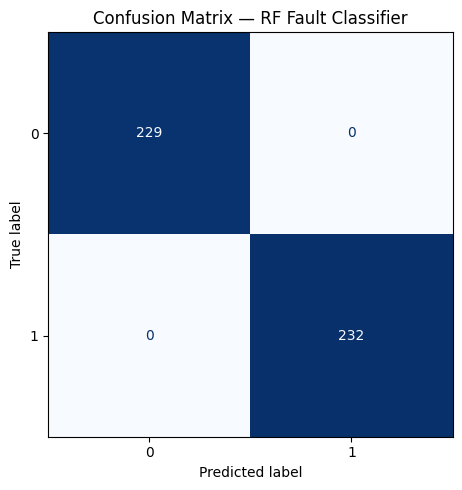

Plot saved → ml_models/rf_confusion_matrix.png


In [17]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — RF Fault Classifier')
plt.tight_layout()
plt.savefig('ml_models/rf_confusion_matrix.png', dpi=150)
plt.show()
print('Plot saved → ml_models/rf_confusion_matrix.png')

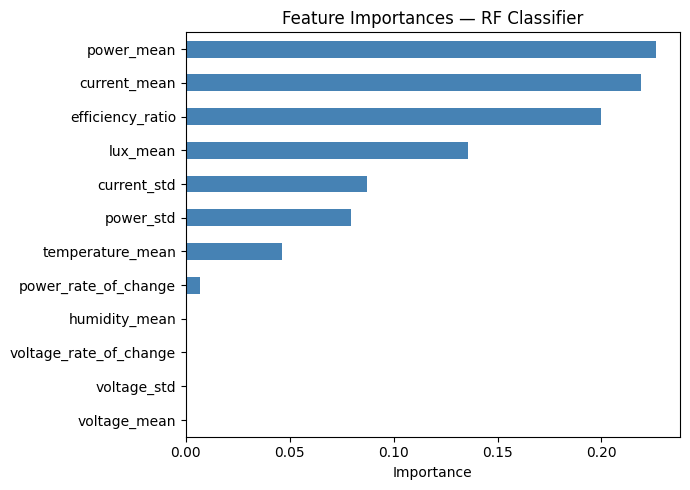

In [18]:
# Feature importances
importances = pd.Series(rf_model.feature_importances_, index=FEATURE_ORDER).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 5))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importances — RF Classifier')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('ml_models/rf_feature_importances.png', dpi=150)
plt.show()

## 5. Save model and verify

In [19]:
pkl_path = 'ml_models/rf_classifier.pkl'
joblib.dump(rf_model, pkl_path)
print(f'Saved → {pkl_path}')

# ── Verify load + predict ─────────────────────────────────────────────────────
loaded_model = joblib.load(pkl_path)
sample = X_test.iloc[:3]
preds = loaded_model.predict(sample)
assert all(p in [0, 1, 2] for p in preds), 'Unexpected prediction values!'
print(f'Verification predictions: {preds} ✓')
print('rf_classifier.pkl saved and verified successfully.')

Saved → ml_models/rf_classifier.pkl
Verification predictions: [2 0 2] ✓
rf_classifier.pkl saved and verified successfully.
